# 11 · Bound a global minimum

**Time:** 110–120 minutes plus lab/homework. **Preparation:** Lectures 06–08 and elementary optimization. **Lab:** [Branch-and-bound with an audit trail](../labs/lab11_global_optimization.ipynb).

Objectives: maintain a lower bound and a feasible upper bound for a global minimum, prune safely, preserve every minimizer, and distinguish a value gap from localization. We use one-dimensional compact domains; two-dimensional optimization is an extension.

In [1]:
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from vc.intervals import RationalInterval as Interval
from vc.enclosures import combined_enclosure
from vc.optimization import minimize

def objective(X):
    return X.square().square() - 2*X.square()

def derivative(X):
    return 4*X*X*X - 4*X

def improved(X):
    return combined_enclosure(objective, derivative, X)

domain = Interval(-2, 2)

## Motivation · Two equally good valleys

Our objective is f(x)=x⁴−2x² on [−2,2]. It has two minima, at x=−1 and x=1, both with value −1. The identity f(x)=(x²−1)²−1 proves this analytically and gives an independent reference.

A local numerical solver might return only one valley. We will instead bound the global minimum value and retain a union of boxes containing **every** global minimizer. We deliberately start with a less sharp expression so that subdivision has work to do.

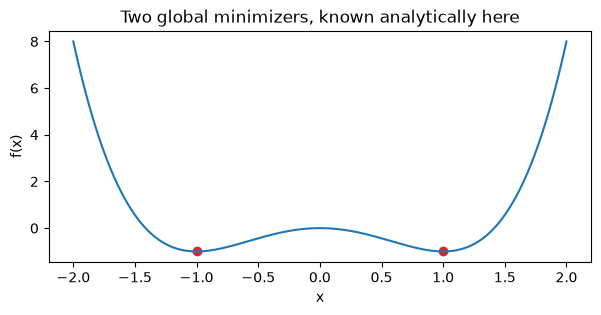

Initial natural range: [-8, 16]


In [2]:
xs = np.linspace(-2, 2, 401)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(xs, xs**4 - 2*xs**2)
ax.scatter([-1, 1], [-1, -1], color="tab:red")
ax.set(xlabel="x", ylabel="f(x)", title="Two global minimizers, known analytically here")
display(fig)
plt.close(fig)
print("Initial natural range:", objective(domain))

## THEORY · Lower bounds and feasible incumbents

Assume f is continuous on the nonempty compact domain D, so its minimum μ is attained. For each retained box X, an enclosing image F(X) gives a lower bound L_X on every f(x) in X.

Choose a **feasible point** z∈D and enclose f(z) in [l,u]. Its upper endpoint U=u satisfies μ≤f(z)≤U. U is our incumbent upper bound. An approximate local minimizer can suggest z, but its value must be enclosed rigorously. Endpoints of D are also feasible and must not be forgotten.

Given boxes that contain all global minimizers, set L=min L_X. Then L≤μ≤U. The minimum of sampled values alone provides an upper bound in exact arithmetic; it supplies no global lower bound.

In [3]:
witness = Fraction(1)
witness_value = objective(Interval(witness))
initial_range = objective(domain)
print("Feasible point:", witness)
print("Certified point value:", witness_value)
print("Initial minimum bound:", Interval(initial_range.lo, witness_value.hi))
assert witness_value.lo == witness_value.hi == -1

Feasible point: 1
Certified point value: [-1, -1]
Initial minimum bound: [-8, -1]


## THEORY · Prune with a strict inequality

If L_X>U, every value on X exceeds a value attainable somewhere in D, so X contains no global minimizer. We may discard it and record the bound and incumbent used.

**Do not prune at equality when promising to retain all minimizers.** A box with L_X=U might contain another equally good minimizer. Our code uses `>`.

Replacing a retained box by two covering children preserves the minimizer set. Improving the feasible incumbent can only lower U. By induction, after any sequence of splits and strict prunes, every minimizer remains in a retained box. This invariant also holds when a budget is exhausted.

## ALGORITHM · A short branch-and-bound loop

1. Evaluate the domain and feasible points (midpoint and both endpoints).
2. Discard boxes whose lower bound is strictly above the incumbent.
3. Select a box with the smallest lower bound; break ties by choosing the wider box.
4. If U−L meets the value tolerance, report `gap_met`.
5. Otherwise split the selected box, evaluate both children, and update the incumbent from their midpoint values.

A split budget gives `budget_exhausted`; an unsplittable point with a wide evaluation gives `precision_limited`. All three outcomes still return a minimum enclosure and retained minimizer boxes under the evaluator premises. The reviewed implementation is [vc/optimization.py](../vc/optimization.py); the lab reconstructs the loop using supplied record and plotting helpers.

In [4]:
results = []
for name, evaluate in [("natural", objective), ("combined", improved)]:
    result = minimize(evaluate, domain, tolerance="1/100", max_splits=512)
    results.append((name, result))
    print(name, result.status, "splits:", result.splits)
    print("Minimum bound:", result.minimum)
    print("Retained boxes:", len(result.candidates))
    assert result.status == "gap_met"
    assert result.minimum.contains(-1)
    assert result.minimum.width() <= Fraction(1, 100)
    for minimizer in [-1, 1]:
        assert any(piece.domain.contains(minimizer) for piece in result.candidates)

result = results[1][1]
assert results[1][1].splits < results[0][1].splits

natural gap_met splits: 175
Minimum bound: [-271098767/268435456, -1]
Retained boxes: 120
combined gap_met splits: 29
Minimum bound: [-1055535/1048576, -1]
Retained boxes: 12


The combined evaluator uses the intersection of natural and mean-value bounds from Lecture 07. Both approaches solve the same mathematical problem. The observed split-count improvement belongs to this example; no theorem says the centered form is always faster.

**CHECKPOINT (10 minutes):** explain why a point evaluation's upper endpoint, rather than its lower endpoint or midpoint, is the safe incumbent.

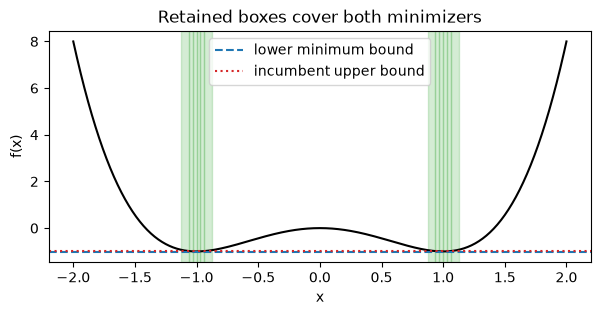

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(xs, xs**4 - 2*xs**2, color="black")
for piece in result.candidates:
    part = piece.domain
    ax.axvspan(float(part.lo), float(part.hi), color="tab:green", alpha=0.2)
ax.axhline(float(result.minimum.lo), color="tab:blue", linestyle="--", label="lower minimum bound")
ax.axhline(float(result.minimum.hi), color="tab:red", linestyle=":", label="incumbent upper bound")
ax.set(xlabel="x", ylabel="f(x)", title="Retained boxes cover both minimizers")
ax.legend()
display(fig)
plt.close(fig)

## AUDIT · Inspect the pruning evidence

Every pruned record includes its local lower bound and the incumbent at that step. Retained and pruned terminal boxes together still cover the original domain. The retained boxes alone need cover only all minimizers. This differs from the complete domain cover used for range enclosure in Lecture 06.

In [6]:
for record in result.pruned[:5]:
    print(record.piece.domain, ":", record.piece.enclosure.lo, ">", record.incumbent_upper)
for record in result.pruned:
    assert record.piece.enclosure.lo > record.incumbent_upper
terminal_domains = [piece.domain for piece in result.candidates]
terminal_domains.extend(record.piece.domain for record in result.pruned)
terminal_domains.sort(key=lambda part: part.lo)
assert terminal_domains[0].lo == domain.lo
assert terminal_domains[-1].hi == domain.hi
for left, right in zip(terminal_domains, terminal_domains[1:]):
    assert left.hi == right.lo

[-2, -7/4] : 9025/4096 > -1
[-7/4, -3/2] : -975/4096 > -1
[3/2, 7/4] : -975/4096 > -1
[7/4, 2] : 9025/4096 > -1
[-1/2, 0] : -1/2 > -1


## Failure of an expectation · A tiny value gap need not localize minimizers

For a constant function every point minimizes. Even an exact minimum value leaves a wide minimizer set. For f(x)=x on [0,1], the minimum is attained at a boundary, and a value-only stopping rule need not shrink its candidate domain.

A small budget is another honest outcome: it can leave a broad minimum enclosure without invalidating the bound.

In [7]:
constant = minimize(lambda X: Interval(3), Interval(-10, 10))
boundary = minimize(lambda X: X, Interval(0, 1))
limited = minimize(improved, domain, tolerance="1/1000000", max_splits=2)
print("Constant function:", constant.status, constant.minimum,
      "candidate width:", constant.candidates[0].domain.width())
print("Boundary minimum:", boundary.minimum, "witness:", boundary.witness)
print("Small budget:", limited.status, limited.minimum)
assert constant.minimum.width() == 0
assert constant.candidates[0].domain.width() == 20
assert boundary.witness == 0
assert limited.status == "budget_exhausted"
assert limited.minimum.contains(-1)

Constant function: gap_met [3, 3] candidate width: 20
Boundary minimum: [0, 0] witness: 0
Small budget: budget_exhausted [-8, -1]


## Exit ticket and reading

Write a certificate statement containing the original domain, the minimum-value interval, the retained union containing all minimizers, the feasible witness and its enclosure, and the stopping status. Explain which parts remain valid after budget exhaustion.

**Reading:** Tucker §5.2.1, pp. 87–89. Monotonicity and convexity tests in §§5.2.2–5.2.3 are extensions; boundary handling matters when adding them. SIAM Challenge Chapter 4 is a later project option, recorded in [the example index](../Doc/siam_challenge_examples.md). Next: [robust geometry](12_robust_geometry.ipynb).